# Project 2 - Autoregressive forecast with autocorrelated loads for a 10 port network

<b>Import Python Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from statsmodels.graphics.tsaplots import plot_acf

<b>Parameters

In [37]:
networkFactor = 100    # To change the characteristics of the network (Y)
cosPhi=0.95            # Value of teta
time=24                # Training Period  
timeForecast=12        # Test Period

lag_wind=0.75  
lag_load=0.75

error_load=0.25
error_wind=0.5

<b>Import data (From Excel file)

In [38]:
Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Info', header=None))
# Information about the slack bus
SlackBus=Info[0,1]
print ("Slack Bus: ", SlackBus,"\n")

# Network Information
Net_Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Y_Data'))
print ("Lines information (Admitances)\n", Net_Info, "\n")

#Power Information (Train)
Power_Info = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)
print ("Power consumption information (time, Bus)\n", Power_Info, "\n")

#Power Information (Test)
Power_Test = np.array(pd.read_excel (r'grid_data.xlsx', sheet_name='Test_Load(t,Bus)'))
Power_Test = np.delete(Power_Test,[0],1)
print ("Power consumption information (time, Bus)\n", Power_Test, "\n")

P = np.dot(-Power_Info, np.exp(complex(0,1)*np.arccos(cosPhi)))  # shape (13, 9)
I = np.conj(P[0, :])   # row 0 = first time step, all 9 buses → shape (9,)


Slack Bus:  1 

Lines information (Admitances)
 [[1 2 '0,01-0,10i']
 [2 3 '0,02-0,15i']
 [3 4 '0,02-0,15i']
 [4 5 '0,03-0,20i']
 [2 6 '0,02-0,18i']
 [3 6 '0,03-0,22i']
 [3 7 '0,03-0,22i']
 [4 7 '0,02-0,18i']
 [6 8 '0,04-0,25i']
 [7 9 '0,04-0,25i']
 [8 10 '0,05-0,30i']
 [9 10 '0,05-0,30i']] 

Power consumption information (time, Bus)
 [[0.5   0.8   0.6   0.3   0.7   0.4   0.5   0.4   0.3  ]
 [0.5   0.707 0.568 0.329 0.298 0.603 0.463 0.439 0.287]
 [0.404 0.324 0.414 0.287 0.165 0.394 0.445 0.375 0.295]
 [0.44  0.366 0.23  0.217 0.068 0.267 0.276 0.493 0.348]
 [0.603 0.167 0.305 0.193 0.03  0.239 0.27  0.387 0.391]
 [0.477 0.072 0.445 0.03  0.03  0.142 0.273 0.656 0.208]
 [0.371 0.03  0.546 0.03  0.11  0.03  0.125 0.632 0.092]
 [0.552 0.47  0.313 0.058 0.49  0.034 0.386 0.435 0.125]
 [0.584 0.396 0.21  0.182 0.453 0.03  0.399 0.241 0.152]
 [0.426 0.083 0.239 0.108 0.439 0.082 0.161 0.263 0.176]
 [0.444 0.268 0.378 0.03  0.358 0.03  0.235 0.197 0.496]
 [0.308 0.03  0.235 0.03  0.03  0.211

<b>Admittance Matrix(<i>Y</i>); Conductance Matrix(<i>G</i>); Susceptance Matrix(<i>B</i>)

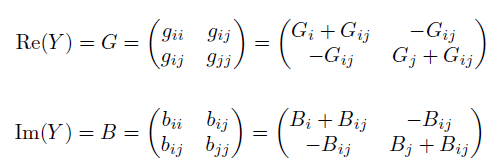

In [39]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex)

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 

print("The admitance matrix Y is:\n", Y, "\n")
print("The conductance matrix G is\n", G, "\n")
print("The susceptance matrix B is\n",B, "\n")

The admitance matrix Y is:
 [[ 1.-10.j -1.+10.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [-1.+10.j  5.-43.j -2.+15.j  0. +0.j  0. +0.j -2.+18.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j -2.+15.j 10.-74.j -2.+15.j  0. +0.j -3.+22.j -3.+22.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -2.+15.j  7.-53.j -3.+20.j  0. +0.j -2.+18.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j -3.+20.j  3.-20.j  0. +0.j  0. +0.j  0. +0.j
   0. +0.j  0. +0.j]
 [ 0. +0.j -2.+18.j -3.+22.j  0. +0.j  0. +0.j  9.-65.j  0. +0.j -4.+25.j
   0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+22.j -2.+18.j  0. +0.j  0. +0.j  9.-65.j  0. +0.j
  -4.+25.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -4.+25.j  0. +0.j  9.-55.j
   0. +0.j -5.+30.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -4.+25.j  0. +0.j
   9.-55.j -5.+30.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -5.+30.j
  -5.+30.j 10.-60.j]] 

The conductance mat

<b> Errors Definition

Random values considering a normal distribution

In [40]:
np.random.seed(50)
e1=np.random.randn(time+timeForecast)*error_wind  #Errors associated to Wind Generation
e  = np.random.randn(nBus-1, time+timeForecast) * error_load  # ← shape (9, 36): one noise series per bus


To obtain the same values of lecture notes, we should use the following errors

<b> Determine the wind generation and the load flow in <i>I<sub>12

In [41]:

#Creation of Matrix
II = np.zeros((nBus-1, time+timeForecast), dtype=complex)
lines = [
    (1,2),(2,3),(3,4),(4,5),
    (2,6),(3,6),(3,7),(4,7),
    (6,8),(7,9),(8,10),(9,10)
]
I_lines = np.zeros((len(lines), time+timeForecast))
i_wind  = np.zeros(time+timeForecast)  

# Initializing the process of data generation
II[:,0]=I                                      #Power Injections
v = 1+np.dot(np.linalg.inv(Yl),I)
v_full = np.insert(v, SlackBus-1, 1.0+0j)          # reinsert slack bus voltage
i_wind[0] = np.real(I[3])                         # Bus 5 is index 3
for k, (bi, bj) in enumerate(lines):
    I_flow = -Y[bi-1, bj-1] * (v_full[bi-1] - v_full[bj-1])
    I_lines[k, 0] = np.absolute(I_flow) * np.sign(np.real(I_flow))

# Process of data generation
for t in range(time+timeForecast-1):             

    II[:, t+1]  = lag_load*II[:, t] + e[:, t]  # Power injection process with noise

    # CORRELATION LINES
    i_wind[t+1]   = lag_wind*i_wind[t] + e1[t]
    II[3,t+1] = i_wind[t+1]+complex(0,np.imag(II[3,t+1]))

    v = 1+np.dot(np.linalg.inv(Yl),II[:,t+1])
    v_full = np.insert(v, SlackBus-1, 1.0+0j)
    for k, (bi, bj) in enumerate(lines):
        I_flow = -Y[bi-1, bj-1] * (v_full[bi-1] - v_full[bj-1])
        I_lines[k, t+1] = np.absolute(I_flow) * np.sign(np.real(I_flow))

    
print('The power injection in Bus 5 (Wind) is:\n', i_wind)
for k, (bi, bj) in enumerate(lines):
    print(f'Power flow in Line {bi}-{bj}:\n', I_lines[k,:])

The power injection in Bus 5 (Wind) is:
 [-0.285      -0.99392605 -0.76093334 -0.88116422 -1.39316341 -0.33889949
 -0.49254069 -0.75964013 -0.03459623 -0.66709347 -1.16405955 -0.80987584
 -0.17631003  0.21613596 -0.00518062 -0.5026485   0.42246777  1.9738885
  1.97430161  1.54265933  1.5283872   0.94931247  0.78604226  0.38341447
  0.20720332  0.22516823  0.31161086  0.09307715  0.92526152  0.61906282
  0.80945047  1.15469261  1.53522381  0.46692702  0.59340908  0.82181765]
Power flow in Line 1-2:
 [ 4.5         4.47762776  2.42540113  1.89983183  2.42638878  0.75456993
  1.16958433  1.17927659  0.83994016  0.83571467  2.1463635   1.77106716
  2.89609253  1.76918304  1.45178772  1.40180547 -0.79687714 -3.27758289
 -2.39130618 -1.27315139 -1.3727336  -0.78830807 -0.63688051 -0.50252388
  0.10091257  0.84132184  0.57554725 -0.53166433 -1.4631487  -0.53986326
 -0.77262307 -1.20783405 -0.54504144  0.09272722 -0.06531875  0.24793956]
Power flow in Line 2-3:
 [ 1.95448122  2.00092256  1.2680

<b>Ordinary Least Squares OLS regression
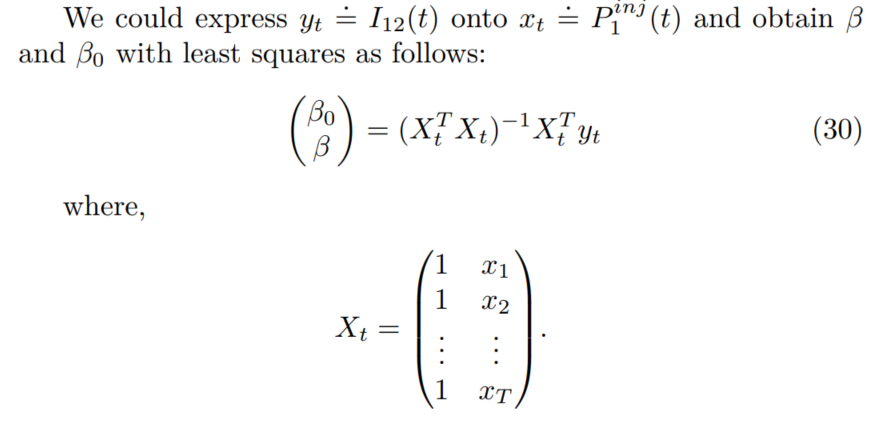

<b>Durbin-Watson statistic
    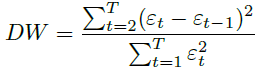

- The Durbin Watson statistic is a test for autocorrelation in a data set.
- The DW statistic always has a value between zero and 4.0.
- A value of 2.0 means there is no autocorrelation detected in the sample. Values from zero to 2.0 indicate positive autocorrelation and values from 2.0 to 4.0 indicate negative autocorrelation.

<sub>https://www.investopedia.com/terms/d/durbin-watson-statistic.asp

<b>Cochrane Orcutt
   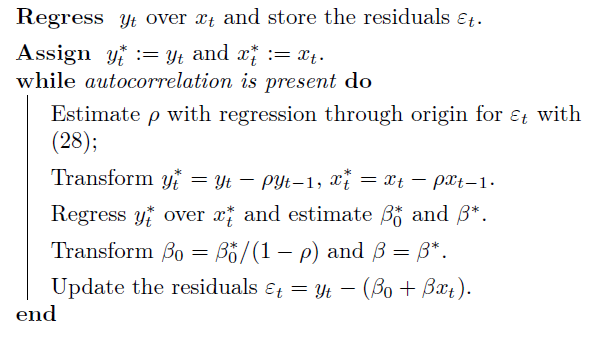

<b>Forecast Day-ahead (Current I_12)

<b>Plot forecsated values

<b>Autocorrelation Method 
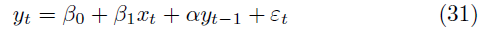
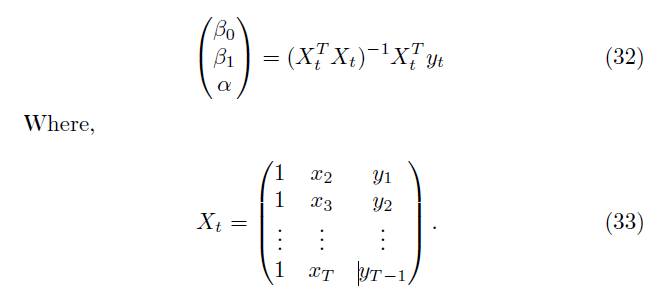

In this example, the input data is different because the error used to generate the values is different. To obtain the same results, we should use the next values. To compare with previous example, we can skip this step.

<b> Models
- 1 - OLS 
- 2 - Cochrane Orcutt (CO)
- 3 - Autorregration AR(1) 
- 4 - Autorregration with Loads AR(1)+Load Sum

## Solvers

In [42]:
print("i_wind range:", i_wind.min(), i_wind.max())
print("I_lines[0] range:", I_lines[0].min(), I_lines[0].max())

i_wind range: -1.393163406708418 1.9743016079499351
I_lines[0] range: -3.277582894617438 4.499999999999996


In [43]:
nL = len(lines)

# Storage for betas and residuals across all lines and methods
beta_OLS     = np.zeros((nL, 2))        # intercept + pv1 + pv2
beta_CO_all  = np.zeros((nL, 2))
beta_AR1_all = np.zeros((nL, 3))        # intercept + pv1 + pv2 + lagged line current
beta_AR1L_all= np.zeros((nL, 4))        # intercept + pv1 + pv2 + lagged + load sum

resid_OLS    = np.zeros((nL, timeForecast))
resid_CO     = np.zeros((nL, timeForecast))
resid_AR1    = np.zeros((nL, timeForecast-1))
resid_AR1L   = np.zeros((nL, timeForecast-1))

DW_OLS  = np.zeros(nL)
DW_CO   = np.zeros(nL)
DW_AR1  = np.zeros(nL)
DW_AR1L = np.zeros(nL)

In [44]:
# Load sum regressor: sum of real power injections across all non-PV, non-slack buses
load_indices = [0, 1, 2, 4, 5, 6, 7, 8]
load_sum = np.sum(np.real(II[load_indices, :]), axis=0)  # shape (time+timeForecast,)

for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]   # current in line k, full time series

    # ── 1. OLS ───────────────────────────────────────────────────────────────
    Xt = np.ones((time, 2))
    Xt[:, 1] = i_wind[0:time]
    XtT = np.transpose(Xt)
    b = np.dot(np.dot(np.linalg.inv(np.dot(XtT, Xt)), XtT), iL[0:time])
    beta_OLS[k] = b

    epsilon = iL[0:time] - (b[0] + b[1]*i_wind[0:time])
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_OLS[k] = np.divide(dw1, dw2)

    iL_out_OLS = b[0] + b[1]*i_wind[time:time+timeForecast]
    resid_OLS[k] = iL[time:time+timeForecast] - iL_out_OLS

    # ── 2. Cochrane-Orcutt ───────────────────────────────────────────────────
    res_1 = iL[0:time] - (b[0] + b[1]*i_wind[0:time])
    for _ in range(3):
        r2 = res_1[0:time-1]
        r1 = res_1[1:time]
        ro = np.dot(r2, r1) / np.dot(r2, r2)

        iL_s    = iL[1:time]    - ro*iL[0:time-1]
        wind_s  = i_wind[1:time] - ro*i_wind[0:time-1]

        B_co = np.ones((time-1, 2))
        B_co[:, 1] = wind_s
        BtB = np.dot(np.transpose(B_co), B_co)
        b_s = np.dot(np.dot(np.linalg.inv(BtB), np.transpose(B_co)), iL_s)
        b_s[0] = b_s[0] / (1 - ro)

        res_2 = iL[0:time] - (b_s[0] + b_s[1]*i_wind[0:time])
        res_1 = res_2[:]
    beta_CO_all[k] = b_s
    epsilon = iL[0:time] - (b_s[0] + b_s[1]*i_wind[0:time])
    
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_CO[k] = np.divide(dw1, dw2)

    iL_out_CO = b_s[0] + b_s[1]*i_wind[time:time+timeForecast]
    resid_CO[k] = iL[time:time+timeForecast] - iL_out_CO

    # ── 3. AR(1) ─────────────────────────────────────────────────────────────
    Xt_AR = np.ones((time-1, 3))
    Xt_AR[:, 1] = i_wind[1:time]
    Xt_AR[:, 2] = iL[0:time-1]
    XtT_AR = np.transpose(Xt_AR)
    b_AR = np.dot(np.dot(np.linalg.inv(np.dot(XtT_AR, Xt_AR)), XtT_AR), iL[1:time])
    beta_AR1_all[k] = b_AR

    epsilon = iL[1:time] - (b_AR[0] + b_AR[1]*i_wind[1:time] + b_AR[2]*iL[0:time-1])
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_AR1[k] = np.divide(dw1, dw2)

    iL_out_AR1 = (b_AR[0] + b_AR[1]*i_wind[time+1:time+timeForecast]+ b_AR[2]*iL[time:time+timeForecast-1])
    resid_AR1[k] = iL[time+1:time+timeForecast] - iL_out_AR1

    # ── 4. AR(1) + Load Sum ──────────────────────────────────────────────────
    Xt_ARL = np.ones((time-1, 4))
    Xt_ARL[:, 1] = i_wind[1:time]
    Xt_ARL[:, 2] = iL[0:time-1]
    Xt_ARL[:, 3] = load_sum[1:time]
    XtT_ARL = np.transpose(Xt_ARL)
    b_ARL = np.dot(np.dot(np.linalg.inv(np.dot(XtT_ARL, Xt_ARL)), XtT_ARL), iL[1:time])
    beta_AR1L_all[k] = b_ARL

    epsilon = (iL[1:time] - (b_ARL[0] + b_ARL[1]*i_wind[1:time] + b_ARL[2]*iL[0:time-1] + b_ARL[3]*load_sum[1:time]))
    dw1 = np.sum((epsilon[1:time-1] - epsilon[0:time-2])**2)
    dw2 = np.sum((epsilon[0:time-2])**2)
    DW_AR1L[k] = np.divide(dw1, dw2)

    iL_out_ARL = (b_ARL[0] + b_ARL[1]*i_wind[time+1:time+timeForecast]
                        + b_ARL[2]*iL[time:time+timeForecast-1]
                        + b_ARL[3]*load_sum[time+1:time+timeForecast])
    resid_AR1L[k] = iL[time+1:time+timeForecast] - iL_out_ARL

# ── Summary print ─────────────────────────────────────────────────────────────
for k, (bi, bj) in enumerate(lines):
    print(f"\nLine {bi}-{bj}:")
    print(f"  OLS  betas={np.round(beta_OLS[k],4)}  DW={DW_OLS[k]:.4f}")
    print(f"  CO   betas={np.round(beta_CO_all[k],4)}  DW={DW_CO[k]:.4f}")
    print(f"  AR1  betas={np.round(beta_AR1_all[k],4)}  DW={DW_AR1[k]:.4f}")
    print(f"  AR1L betas={np.round(beta_AR1L_all[k],4)}  DW={DW_AR1L[k]:.4f}")


Line 1-2:
  OLS  betas=[ 0.9064 -1.6583]  DW=0.5965
  CO   betas=[ 0.531  -1.3803]  DW=0.4493
  AR1  betas=[ 0.4151 -1.0583  0.3597]  DW=1.4575
  AR1L betas=[ 0.0082 -0.9943  0.0171 -0.9985]  DW=0.3767

Line 2-3:
  OLS  betas=[ 0.4162 -0.7699]  DW=0.6236
  CO   betas=[ 0.2599 -0.6564]  DW=0.5010
  AR1  betas=[ 0.2004 -0.503   0.3515]  DW=1.4664
  AR1L betas=[-0.0016 -0.4539  0.0299 -0.4648]  DW=1.7758

Line 3-4:
  OLS  betas=[ 0.2343 -0.7519]  DW=1.1521
  CO   betas=[ 0.2183 -0.6992]  DW=0.9142
  AR1  betas=[ 0.2181 -0.7351  0.0198]  DW=1.1365
  AR1L betas=[ 0.1592 -0.6943  0.0067 -0.0834]  DW=1.3769

Line 4-5:
  OLS  betas=[ 1.0000e-03 -1.0005e+00]  DW=0.8310
  CO   betas=[ 2.0000e-04 -1.0001e+00]  DW=0.7271
  AR1  betas=[ 4.0000e-04 -1.0002e+00  1.0000e-04]  DW=0.7370
  AR1L betas=[ 1.000e-04 -9.999e-01  2.000e-04 -3.000e-04]  DW=0.6078

Line 2-6:
  OLS  betas=[ 0.3892 -0.7407]  DW=0.6703
  CO   betas=[ 0.2148 -0.5737]  DW=0.4795
  AR1  betas=[ 0.1504 -0.423   0.414 ]  DW=1.4919
  A

In [45]:
# Check residual autocorrelation for line 0 (Bus 1-2) after OLS fit
k = 0
iL = I_lines[k, :]
b  = beta_OLS[k]
fitted    = b[0] + b[1]*i_wind[0:time]
residuals = iL[0:time] - fitted

# Lag-1 autocorrelation
r0 = residuals - np.mean(residuals)
ac = np.dot(r0[1:], r0[:-1]) / np.dot(r0, r0)
print(f"Lag-1 residual autocorrelation: {ac:.4f}")
print(f"DW statistic: {DW_OLS[k]:.4f}  (expect ~2*(1-ac))")

Lag-1 residual autocorrelation: 0.5029
DW statistic: 0.5965  (expect ~2*(1-ac))


In [46]:
for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]
    b  = beta_OLS[k]
    fitted    = b[0] + b[1]*i_wind[0:time]
    residuals = iL[0:time] - fitted
    r0 = residuals - np.mean(residuals)
    ac = np.dot(r0[1:], r0[:-1]) / np.dot(r0, r0)
    print(f"Line {bi}-{bj}: lag-1 autocorr = {ac:.4f},  DW = {DW_OLS[k]:.4f}")

Line 1-2: lag-1 autocorr = 0.5029,  DW = 0.5965
Line 2-3: lag-1 autocorr = 0.5190,  DW = 0.6236
Line 3-4: lag-1 autocorr = 0.4263,  DW = 1.1521
Line 4-5: lag-1 autocorr = 0.1262,  DW = 0.8310
Line 2-6: lag-1 autocorr = 0.4836,  DW = 0.6703
Line 3-6: lag-1 autocorr = 0.5390,  DW = 0.8915
Line 3-7: lag-1 autocorr = 0.4877,  DW = 0.7972
Line 4-7: lag-1 autocorr = 0.4240,  DW = 1.1035
Line 6-8: lag-1 autocorr = 0.4585,  DW = 0.8362
Line 7-9: lag-1 autocorr = 0.6638,  DW = 0.6788
Line 8-10: lag-1 autocorr = 0.1502,  DW = 1.6363
Line 9-10: lag-1 autocorr = 0.1288,  DW = 1.5900


In [47]:
import numpy as np
from tabulate import tabulate

metrics = []
for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]
    real_AR  = iL[time+1:time+timeForecast]   # length 11 (AR methods)
    real_OLS = iL[time:time+timeForecast]      # length 12 (OLS/CO methods)

    b_OLS = beta_OLS[k]
    b_CO  = beta_CO_all[k]
    b_AR1 = beta_AR1_all[k]
    b_ARL = beta_AR1L_all[k]

    # Forecast calculations
    fc_OLS = b_OLS[0] + b_OLS[1]*i_wind[time:time+timeForecast]
    fc_CO  = b_CO[0]  + b_CO[1]*i_wind[time:time+timeForecast] 
    fc_AR1 = (b_AR1[0] + b_AR1[1]*i_wind[time+1:time+timeForecast]
                       + b_AR1[2]*iL[time:time+timeForecast-1])
    fc_ARL = (b_ARL[0] + b_ARL[1]*i_wind[time+1:time+timeForecast]
                       + b_ARL[2]*iL[time:time+timeForecast-1]
                       + b_ARL[3]*load_sum[time+1:time+timeForecast])

    # Metric functions
    def mae(real, fc): return np.mean(np.abs(real - fc))
    def rmse(real, fc): return np.sqrt(np.mean((real - fc)**2))
    def max_err(real, fc): return np.max(np.abs(real - fc)) # New metric

    metrics.append([
        f"{bi}-{bj}",
        f"{mae(real_OLS, fc_OLS):.4f}", f"{rmse(real_OLS, fc_OLS):.4f}", f"{max_err(real_OLS, fc_OLS):.4f}",
        f"{mae(real_OLS, fc_CO):.4f}",  f"{rmse(real_OLS, fc_CO):.4f}",  f"{max_err(real_OLS, fc_CO):.4f}",
        f"{mae(real_AR,  fc_AR1):.4f}", f"{rmse(real_AR,  fc_AR1):.4f}", f"{max_err(real_AR,  fc_AR1):.4f}",
        f"{mae(real_AR,  fc_ARL):.4f}", f"{rmse(real_AR,  fc_ARL):.4f}", f"{max_err(real_AR,  fc_ARL):.4f}",
    ])

# Expanded headers
headers = ["Line",
           "OLS MAE", "OLS RMSE", "OLS MAX",
           "CO MAE",  "CO RMSE",  "CO MAX",
           "AR1 MAE", "AR1 RMSE", "AR1 MAX",
           "ARL MAE", "ARL RMSE", "ARL MAX"]

print(tabulate(metrics, headers=headers, tablefmt="rounded_outline"))

# Overall average across all lines
arr = np.array([[float(v) for v in row[1:]] for row in metrics])
avg = np.mean(arr, axis=0)
print("\nAverage across all lines:")
print(tabulate([["AVG"] + [f"{v:.4f}" for v in avg]], headers=headers, tablefmt="rounded_outline"))

╭────────┬───────────┬────────────┬───────────┬──────────┬───────────┬──────────┬───────────┬────────────┬───────────┬───────────┬────────────┬───────────╮
│ Line   │   OLS MAE │   OLS RMSE │   OLS MAX │   CO MAE │   CO RMSE │   CO MAX │   AR1 MAE │   AR1 RMSE │   AR1 MAX │   ARL MAE │   ARL RMSE │   ARL MAX │
├────────┼───────────┼────────────┼───────────┼──────────┼───────────┼──────────┼───────────┼────────────┼───────────┼───────────┼────────────┼───────────┤
│ 1-2    │    0.4901 │     0.6267 │    1.2837 │   0.4802 │    0.5792 │   1.0431 │    0.4884 │     0.604  │    1.099  │    0.0095 │     0.0117 │    0.0231 │
│ 2-3    │    0.249  │     0.2784 │    0.4517 │   0.2314 │    0.277  │   0.505  │    0.2252 │     0.2812 │    0.4614 │    0.1174 │     0.1289 │    0.2192 │
│ 3-4    │    0.1751 │     0.2012 │    0.3335 │   0.1831 │    0.213  │   0.3662 │    0.172  │     0.2    │    0.3329 │    0.1449 │     0.1756 │    0.2669 │
│ 4-5    │    0.0007 │     0.0007 │    0.0009 │   0.0002 │    0.

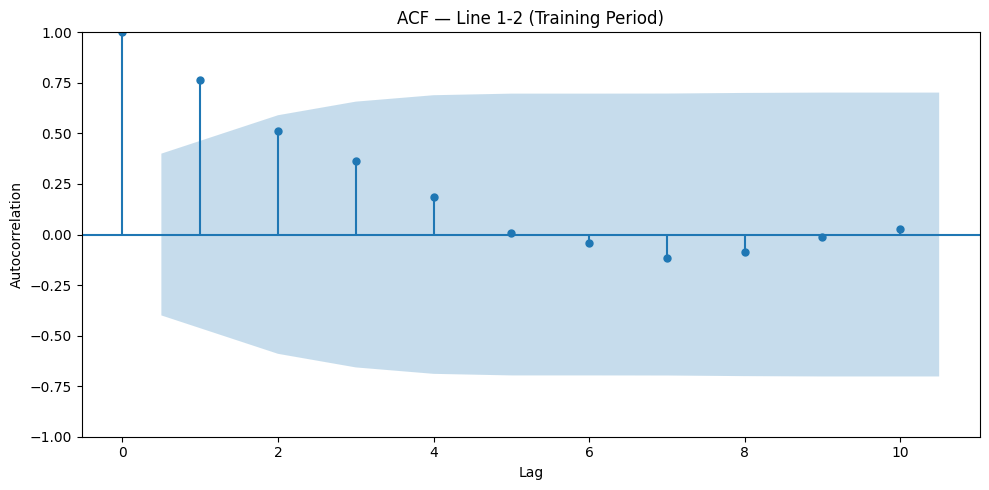

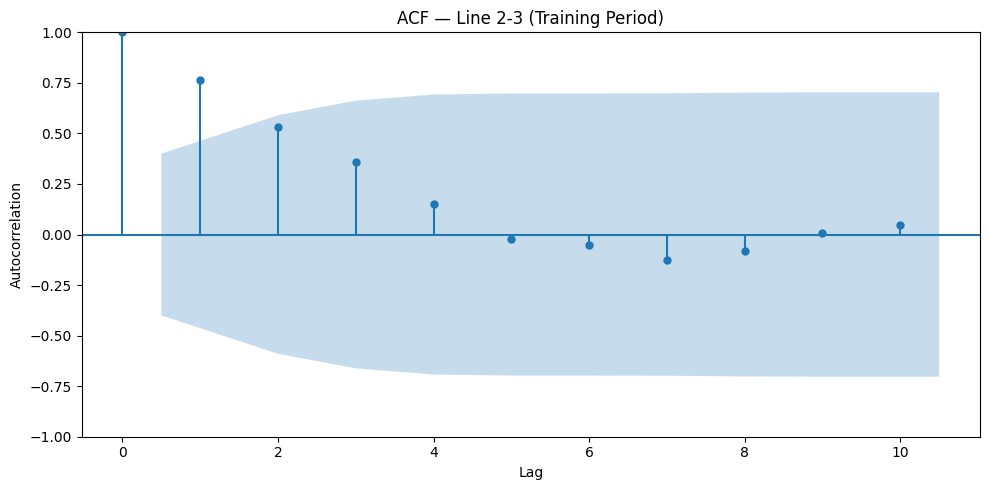

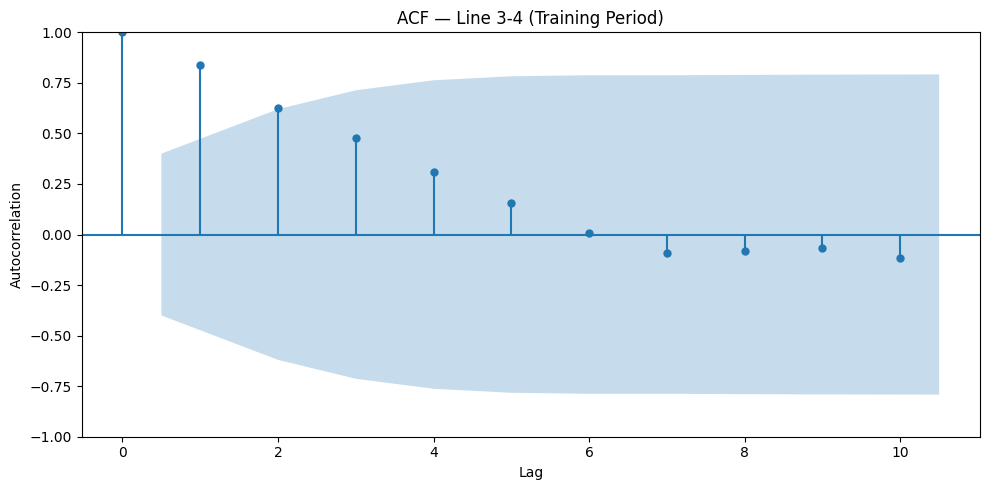

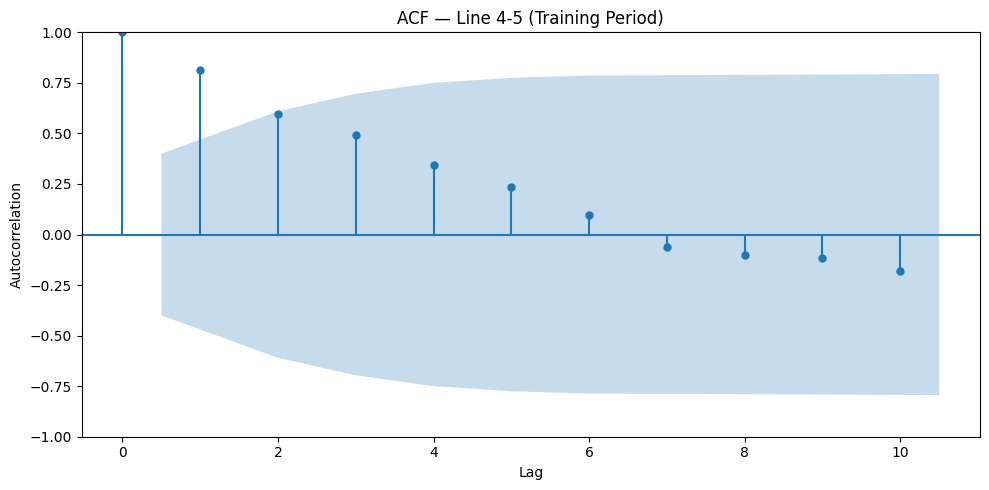

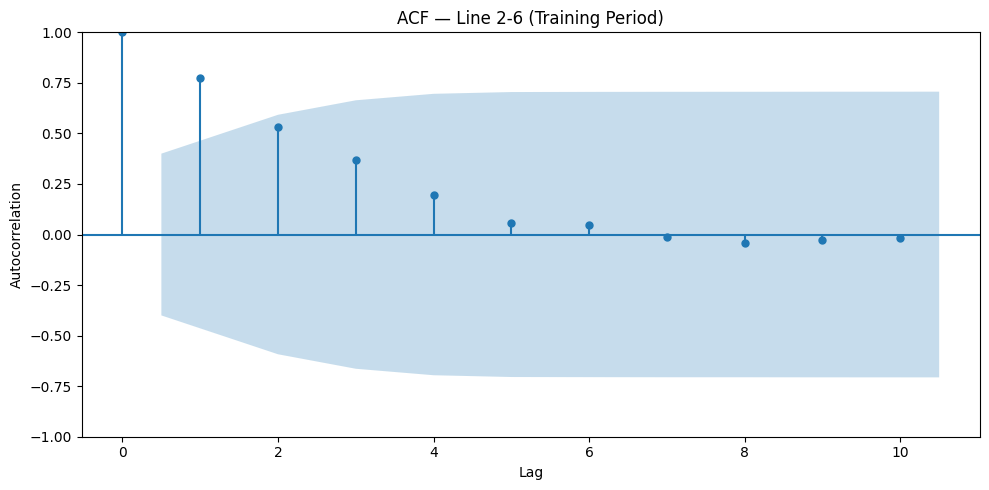

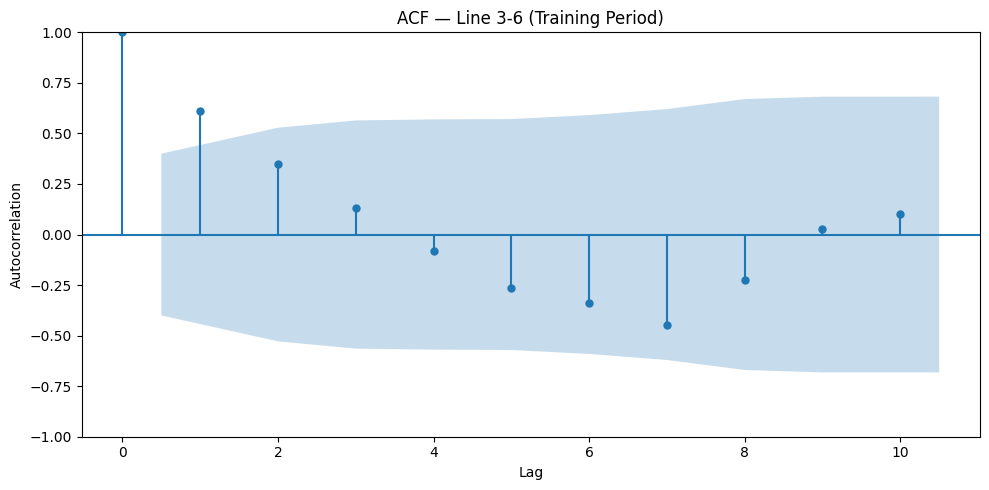

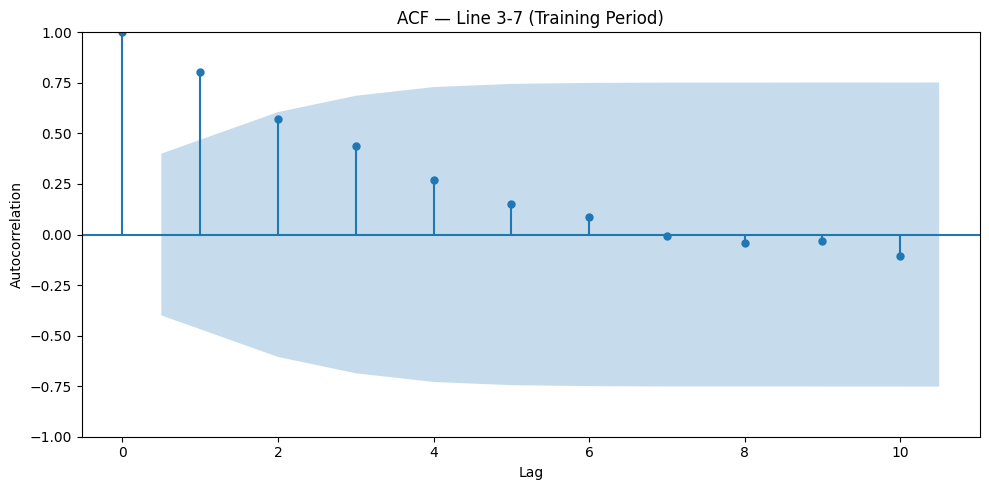

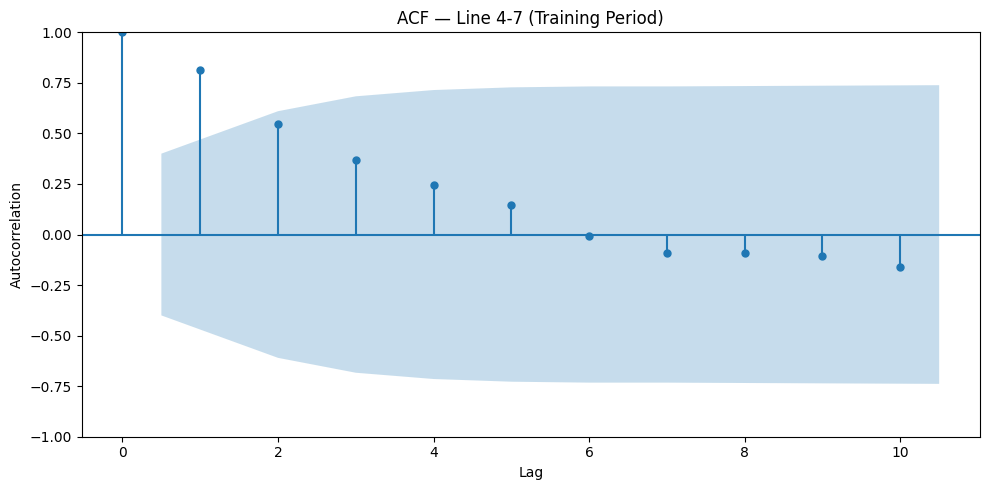

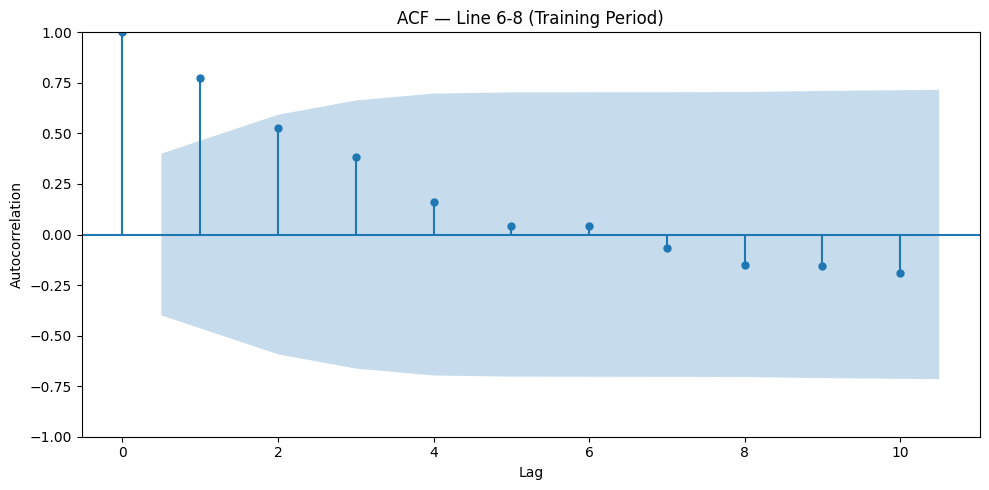

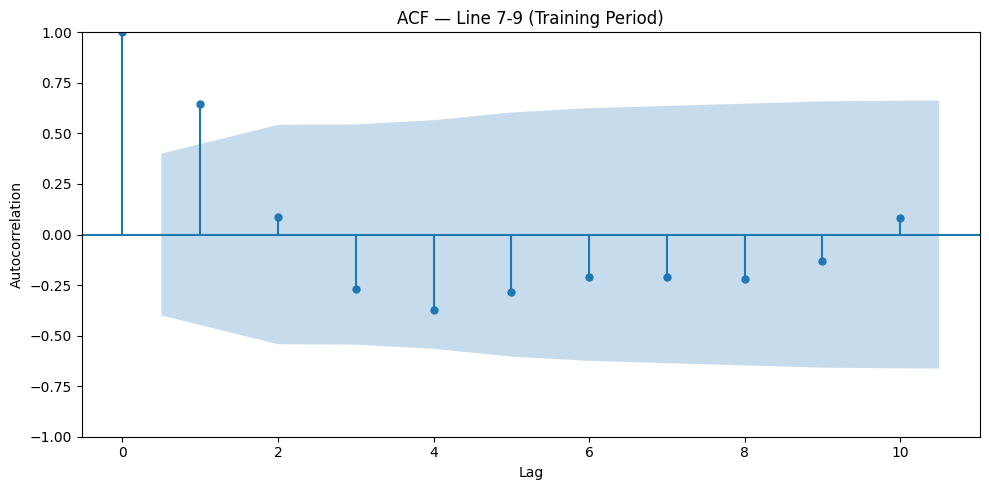

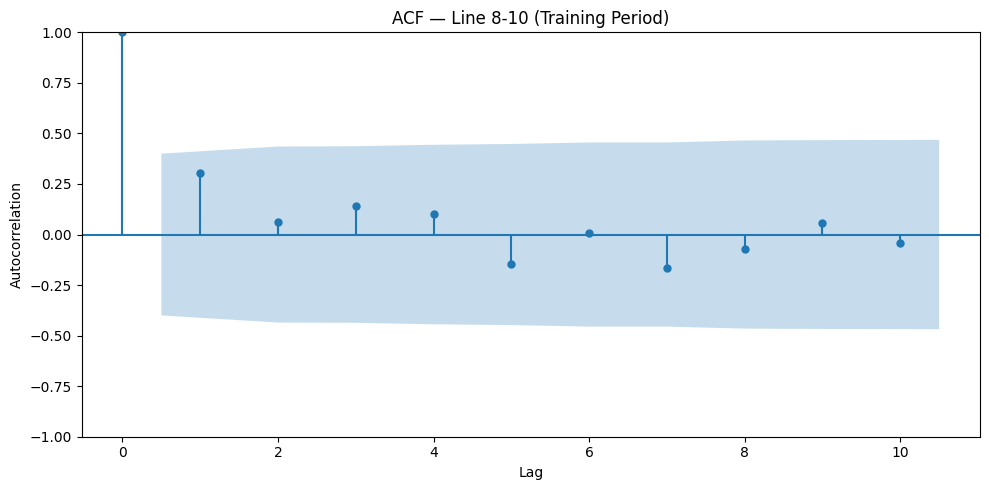

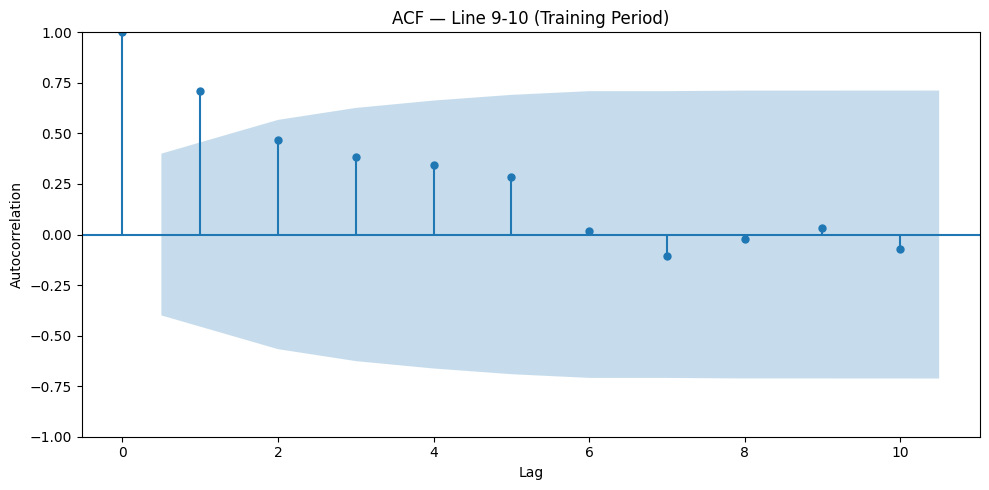

In [48]:
n_lags = 10  # how many lags to show

for k, (bi, bj) in enumerate(lines):
    # 1. Create a new figure and axis for every line
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # 2. Plot the ACF onto the specific axis 'ax'
    plot_acf(I_lines[k, :time], lags=n_lags, ax=ax, alpha=0.05)
    
    # 3. Style the individual plot
    ax.set_title(f"ACF — Line {bi}-{bj} (Training Period)")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    
    plt.tight_layout()
    
    # 4. Either show the plot or save it to a unique file
    plt.show() 


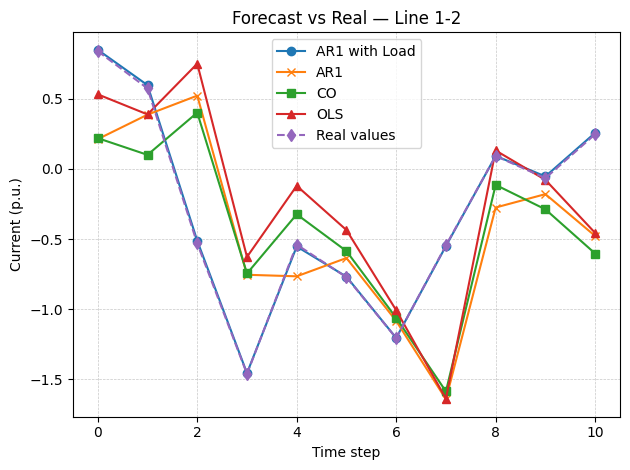

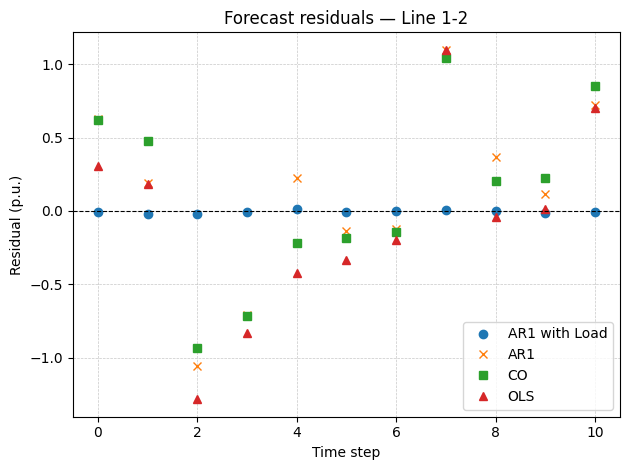

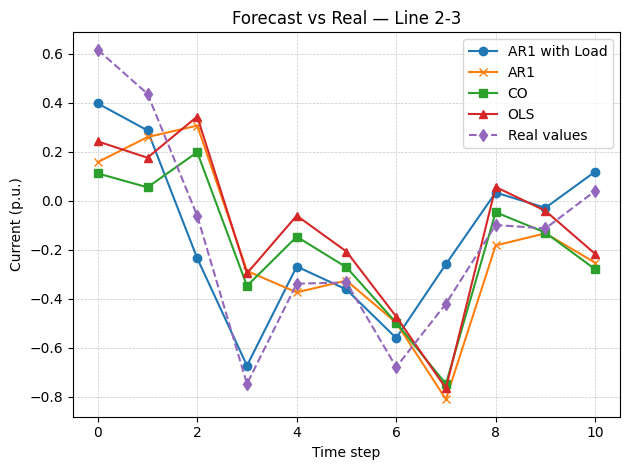

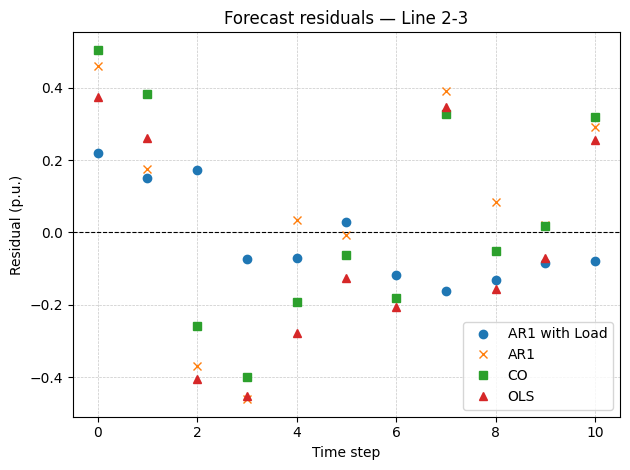

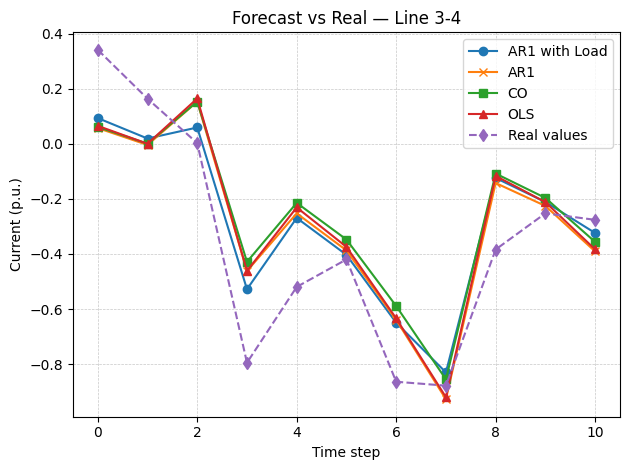

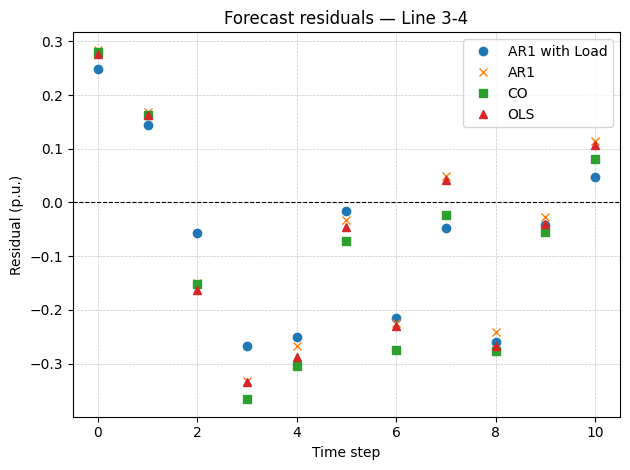

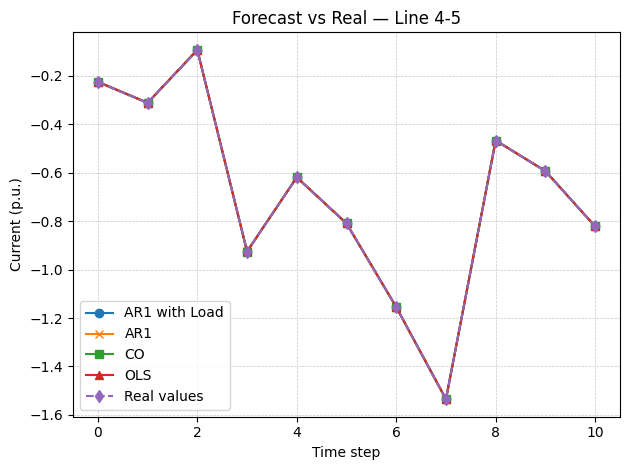

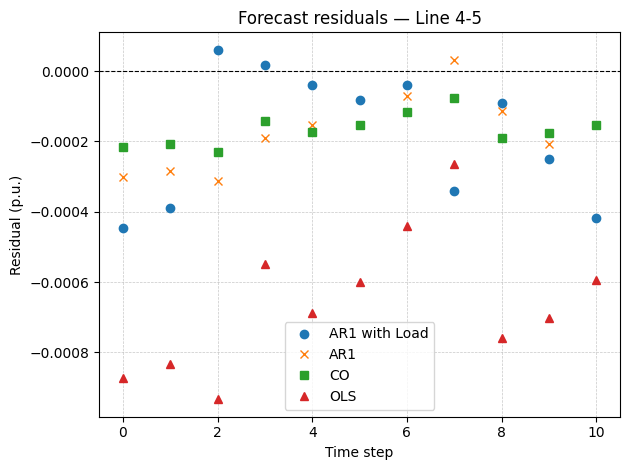

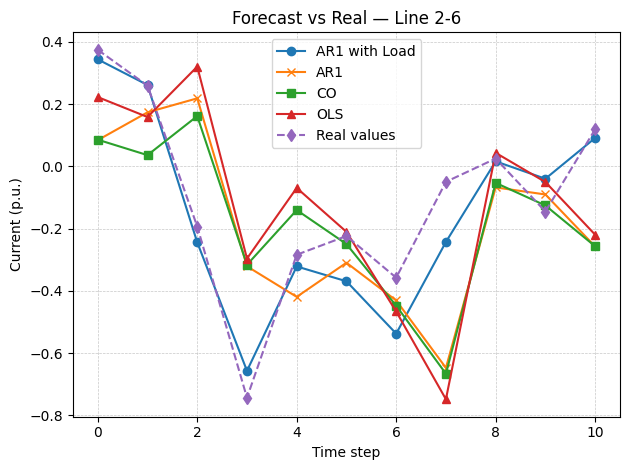

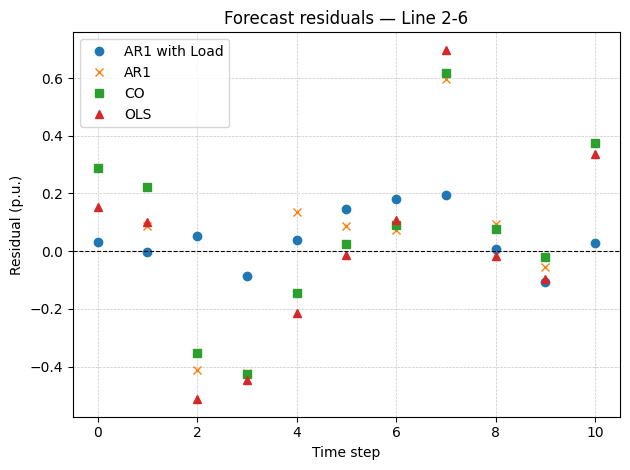

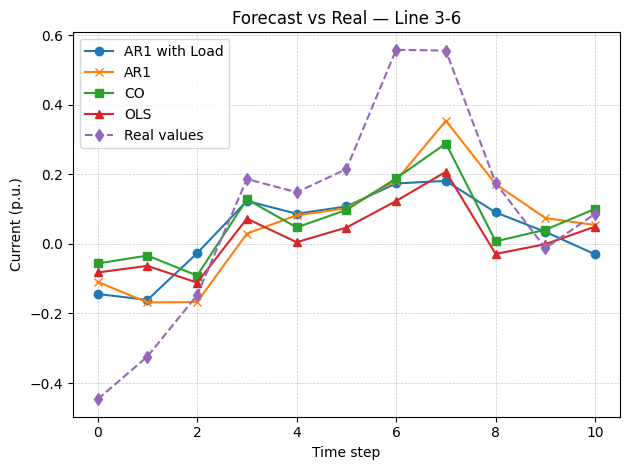

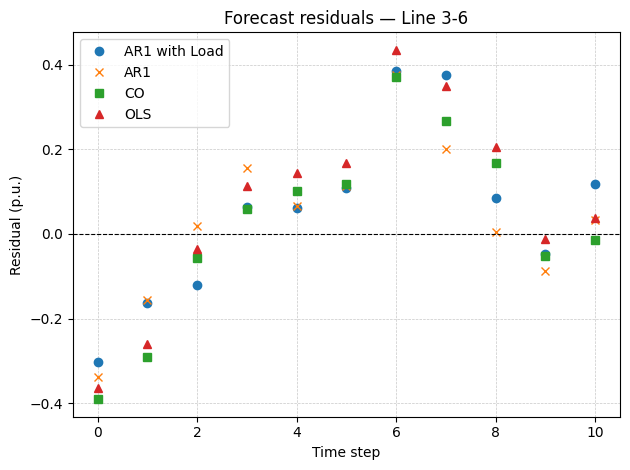

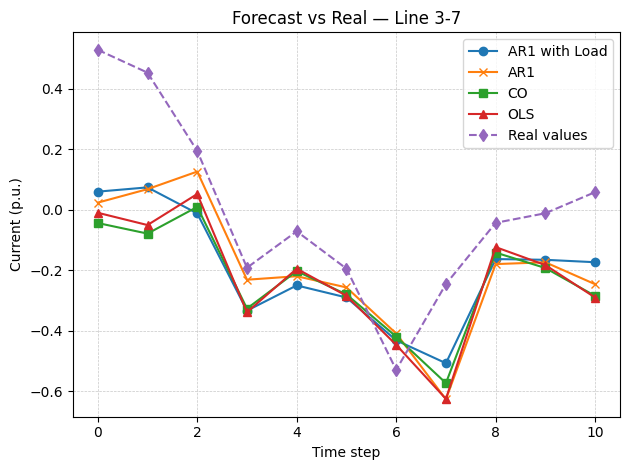

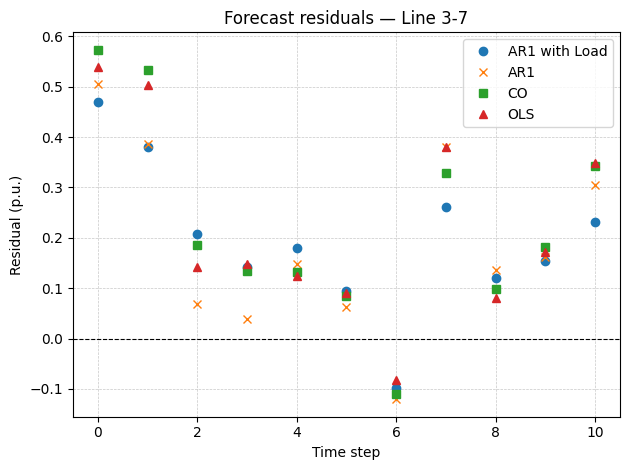

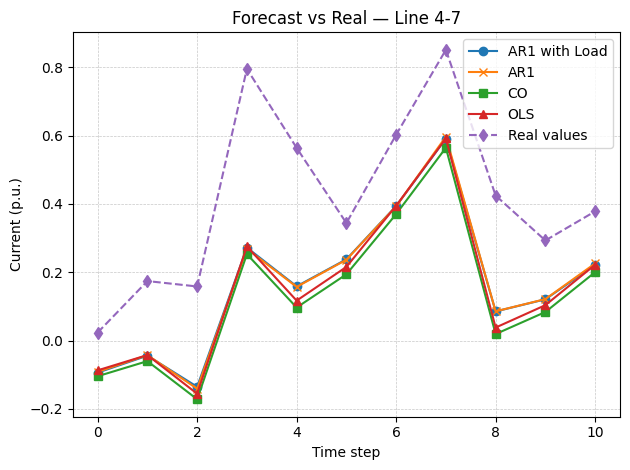

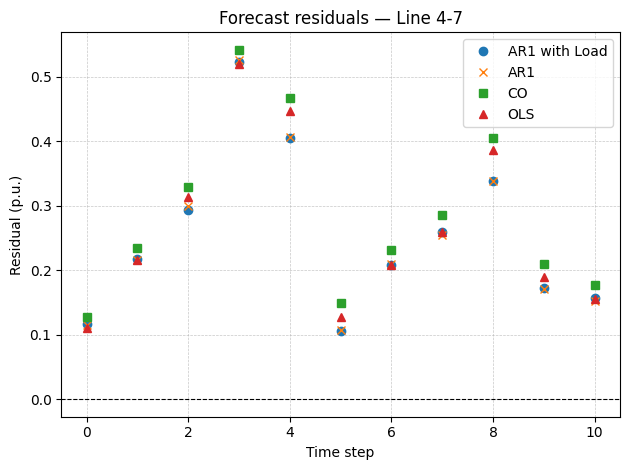

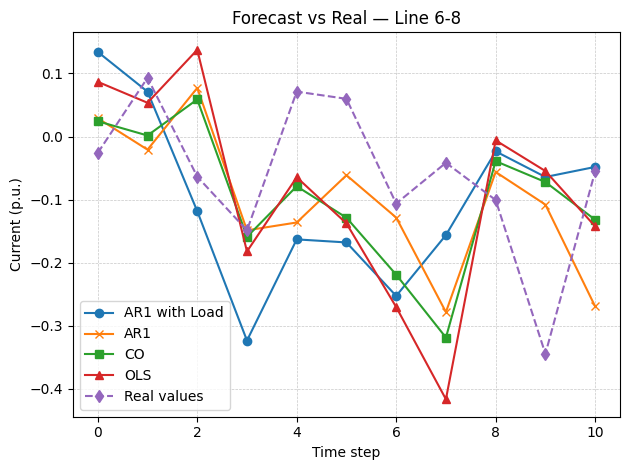

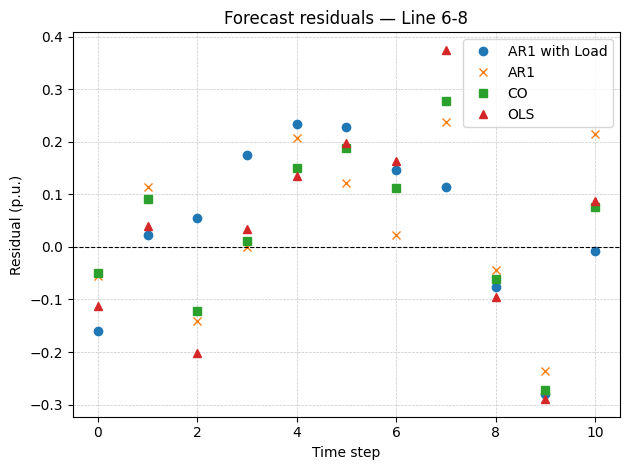

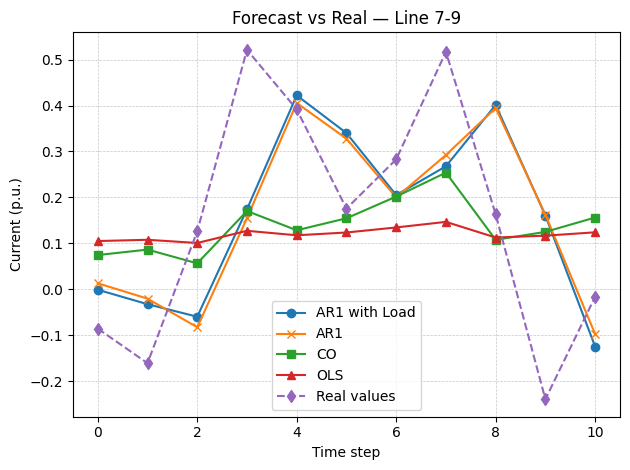

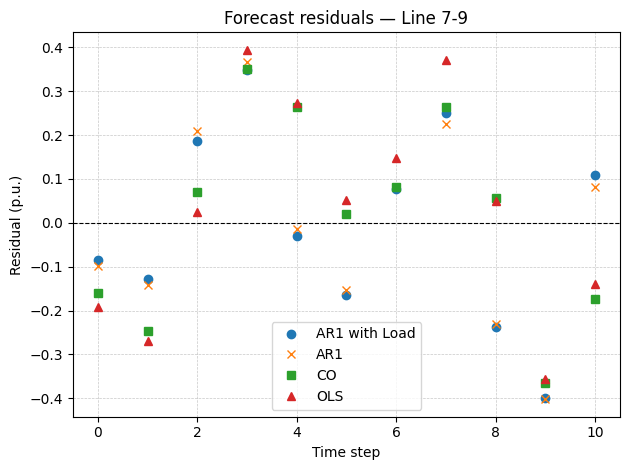

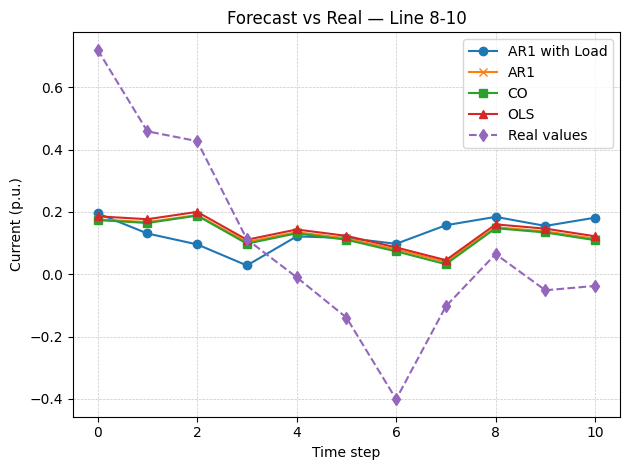

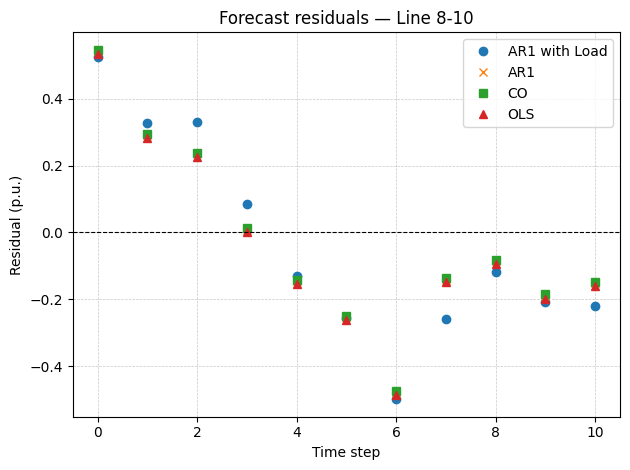

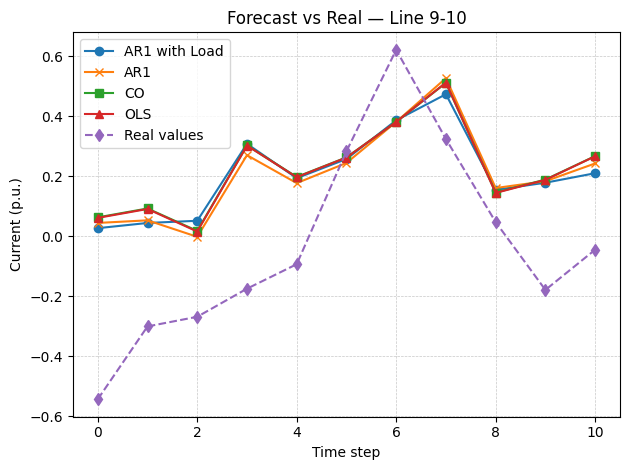

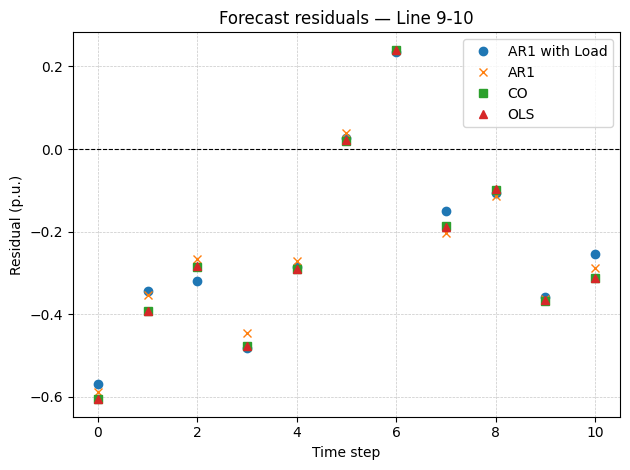

In [49]:
for k, (bi, bj) in enumerate(lines):
    iL = I_lines[k, :]
    real_values = iL[time+1:time+timeForecast]

    b_OLS  = beta_OLS[k]
    b_CO   = beta_CO_all[k]
    b_AR1  = beta_AR1_all[k]
    b_ARL  = beta_AR1L_all[k]

    fc_OLS = b_OLS[0] + b_OLS[1]*i_wind[time:time+timeForecast]

    fc_CO  = b_CO[0]  + b_CO[1]*i_wind[time:time+timeForecast]

    fc_AR1 = (b_AR1[0] + b_AR1[1]*i_wind[time+1:time+timeForecast]
                       + b_AR1[2]*iL[time:time+timeForecast-1])

    fc_ARL = (b_ARL[0] + b_ARL[1]*i_wind[time+1:time+timeForecast]
                       + b_ARL[2]*iL[time:time+timeForecast-1]
                       + b_ARL[3]*load_sum[time+1:time+timeForecast])
    
    

    x = np.arange(len(fc_AR1))

    # ── Forecast plot ─────────────────────────────────────────────────────────
    plt.figure()
    plt.plot(x, fc_ARL,        label="AR1 with Load", marker='o')
    plt.plot(x, fc_AR1,        label="AR1",           marker='x')
    plt.plot(x, fc_CO[1:],     label="CO",            marker='s')
    plt.plot(x, fc_OLS[1:],    label="OLS",           marker='^')
    plt.plot(x, real_values,   label="Real values",   marker='d', linestyle='--')
    plt.xlabel("Time step")
    plt.ylabel("Current (p.u.)")
    plt.title(f"Forecast vs Real — Line {bi}-{bj}")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

    # ── Residuals plot ────────────────────────────────────────────────────────
    plt.figure()
    plt.plot(x, real_values - fc_ARL,     label="AR1 with Load", marker='o', linestyle='None')
    plt.plot(x, real_values - fc_AR1,     label="AR1",           marker='x', linestyle='None')
    plt.plot(x, real_values - fc_CO[1:],  label="CO",            marker='s', linestyle='None')
    plt.plot(x, real_values - fc_OLS[1:], label="OLS",           marker='^', linestyle='None')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.xlabel("Time step")
    plt.ylabel("Residual (p.u.)")
    plt.title(f"Forecast residuals — Line {bi}-{bj}")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()